In [94]:
"""
Get the optimal manipulability points
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.patches as patches


# 设置全局字体为 Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = 'Times New Roman'

In [95]:
marker_idx = 42
mani_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 21, 32, 43, 54, 65, 76, 87, 98, 109, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120]
top_list = [1, 2, 3, 4, 5, 6, 7, 8, 9]
right_list = [21, 32, 43, 54, 65, 76, 87, 98, 109]
bottom_list = [111, 112, 113, 114, 115, 116, 117, 118, 119]
corner_idx = [10, 120]

mani_dx_dy = np.loadtxt('mani_dx_dy.csv', delimiter=',')

mani_j = mani_dx_dy[marker_idx*2:marker_idx*2+2, :]

area_list = []
for idx in range(len(mani_list)):
    j = mani_j[:, idx*2:idx*2+2]
    u, s, v = np.linalg.svd(j)
    if mani_list[idx] in corner_idx:
        area_tmp = s[0] * s[1] * np.pi * 1 * 3/ 4
    else:
        area_tmp = s[0] * s[1] * np.pi * 1 / 2
    area_list.append(area_tmp)

print(area_list)

[0.00268856738086315, 0.010632234678837128, 0.0239627117616318, 0.0393423593958663, 0.05788106276366799, 0.07619466521060594, 0.08896112898500985, 0.09778068492672834, 0.10088570250990622, 0.12922512658309215, 0.1370786705437299, 0.18957231678521716, 0.23586406185370692, 0.17965447339886007, 0.1328574605300887, 0.09449319067687717, 0.07225105029323824, 0.051909854218161015, 0.0374256667498587, 7.739194121599808e-06, 0.0008849932949847251, 0.0035296461993997953, 0.006691905716588661, 0.011369066254544364, 0.016175490333426492, 0.019572585610497576, 0.022393900825575387, 0.02407605805895403, 0.03200054262803701]


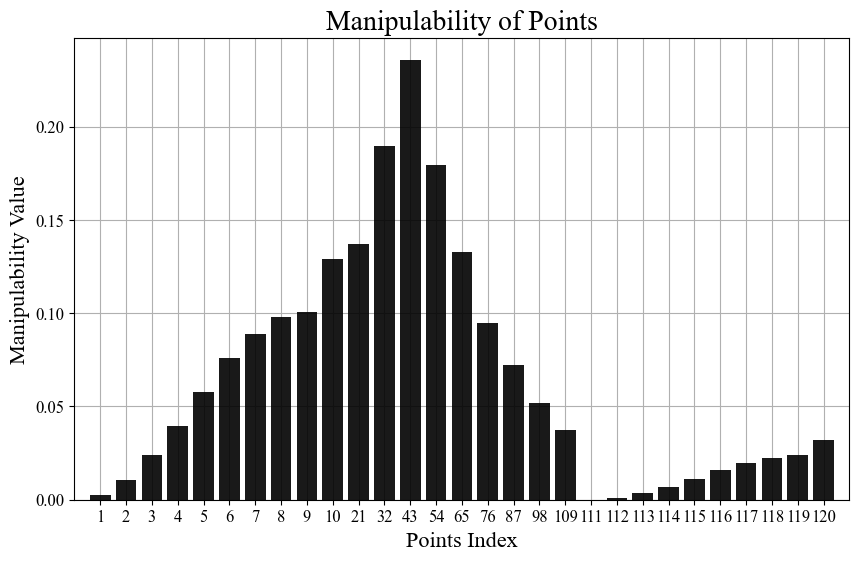

In [96]:
"""
条状图绘制操作点的可操作性值
"""
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title('Manipulability of Points', fontsize=20, fontname='Times New Roman')
ax.set_xlabel('Points Index', fontsize=16, fontname='Times New Roman')
ax.set_ylabel('Manipulability Value', fontsize=16, fontname='Times New Roman')
ax.tick_params(axis='both', which='major', labelsize=12)    # 设置刻度标签大小
plt.gca().get_yaxis().get_offset_text().set_fontsize(12)    # 设置坐标轴刻度值的大小

bars = ax.bar(range(len(mani_list)), area_list, color='k', alpha=0.9, zorder=3)
ax.set_xlim(-1, len(mani_list))
ax.set_xticks(ticks=range(len(mani_list)), labels=mani_list)
ax.grid(True, zorder=2)

plt.show()

In [101]:
start_x, start_xx = np.array([1, 0]), np.array([-1, 0])
j_tmp = mani_j[:, 9*2:9*2+2]
print('J', j_tmp)

end_x_ = np.dot(j_tmp, start_x)
end_xx_ = np.dot(j_tmp, start_xx)

u, s, v = np.linalg.svd(j_tmp)
if np.linalg.det(u) < 0:
    u[:, 1] = -u[:, 1]      # y axis flip
    
# if np.linalg.det(v) < 0:
#     v[1, :] = -v[1, :]      # y axis flip v.T

end_x = np.dot(np.diag(s)@v.T, start_x)
end_xx = np.dot(np.diag(s)@v.T, start_xx)

start_ang = np.degrees(np.arctan2(end_x[1], end_x[0]))
end_ang = np.degrees(np.arctan2(end_xx[1], end_xx[0]))

rot_ang = np.degrees(np.arctan2(u[1,0], u[0,0]))
print(s)
print(rot_ang)
print(start_ang, end_ang)

J [[1.36588e-01 3.73000e-04]
 [7.32790e-02 4.01735e-01]]
[0.40921192 0.13402554]
86.09430810272954
57.88090053295515 -122.11909946704485


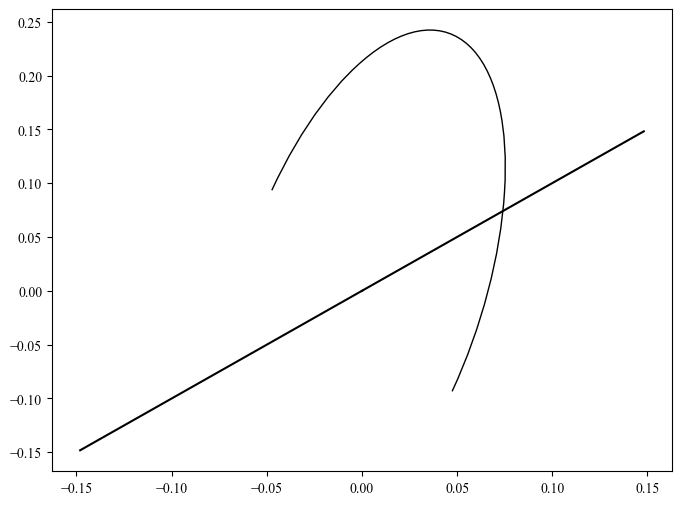

In [99]:
fig, ax = plt.subplots(figsize=(8,6))

# 定义椭圆圆弧的参数
# 中心点坐标、宽度、高度、旋转角度、开始角度、结束角度
ellipse_arc = patches.Arc((0., 0.), s[0], s[1], angle=rot_ang, theta1=end_ang, theta2=start_ang, color='k', linewidth=1)

# 将椭圆圆弧添加到子图上
ax.add_patch(ellipse_arc)
ax.plot([0., end_x_[0]], [0., end_x_[1]], color='k')
ax.plot([0., end_xx_[0]], [0., end_xx_[1]], color='k')

# # 设置轴的范围
# ax.set_xlim(-5.e-5, 5.e-5)
# ax.set_ylim(-5.e-5, 5.e-5)

plt.show()